<a href="https://colab.research.google.com/github/Chimatanagagopal/DEEP-LEARNING_practice/blob/main/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb

VOCAB_SIZE = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print(f"Training reviews:   {len(X_train)}")
print(f"Testing reviews:    {len(X_test)}")
print(f"\nSample label:       {y_train[0]} (1=positive, 0=negative)")
print(f"Sample review:      {X_train[0][:10]} ...")
print(f"Review length:      {len(X_train[0])} words")
print(f"\nShortest review:    {min(len(x) for x in X_train)} words")
print(f"Longest review:     {max(len(x) for x in X_train)} words")
print(f"Average length:     {int(np.mean([len(x) for x in X_train]))} words")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training reviews:   25000
Testing reviews:    25000

Sample label:       1 (1=positive, 0=negative)
Sample review:      [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65] ...
Review length:      218 words

Shortest review:    11 words
Longest review:     2494 words
Average length:     238 words


In [3]:
word_index = imdb.get_word_index()

index_to_word = {v+3: k for k, v in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join([index_to_word.get(i, "?")
                     for i in encoded_review])

print("ENCODED (what RNN sees):")
print(X_train[0][:15])
print(f"\nDECODED (actual review):")
print(decode_review(X_train[0])[:300])
print(f"\nLabel: {'POSITIVE ✅' if y_train[0]==1 else 'NEGATIVE ❌'}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ENCODED (what RNN sees):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]

DECODED (actual review):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the

Label: POSITIVE ✅


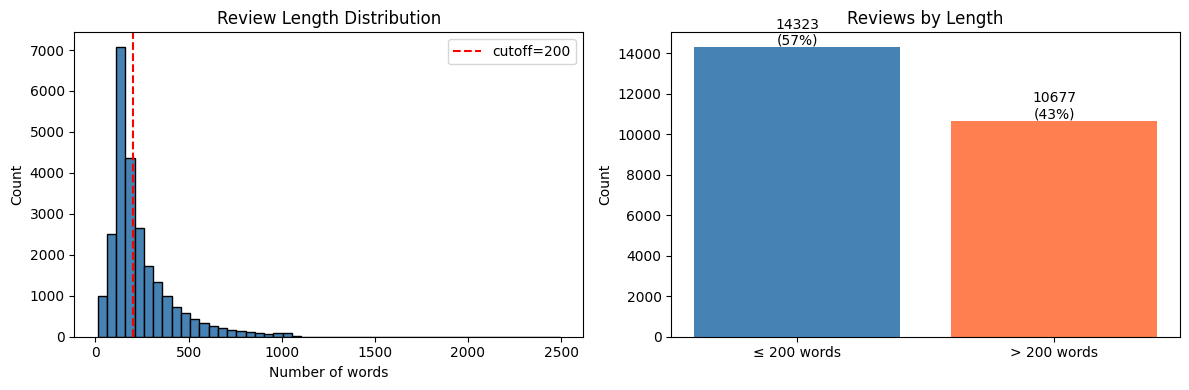

Reviews ≤ 200 words: 14323 (57%)
Reviews > 200 words: 10677  (43%)


In [4]:
lengths = [len(x) for x in X_train]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(lengths, bins=50, color="steelblue", edgecolor="black")
plt.axvline(x=200, color="red", linestyle="--", label="cutoff=200")
plt.title("Review Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()

plt.subplot(1, 2, 2)
under_200 = sum(1 for l in lengths if l <= 200)
over_200  = sum(1 for l in lengths if l > 200)
plt.bar(["≤ 200 words", "> 200 words"],
        [under_200, over_200],
        color=["steelblue", "coral"])
plt.title("Reviews by Length")
plt.ylabel("Count")
for i, v in enumerate([under_200, over_200]):
    plt.text(i, v+100, f"{v}\n({v/len(lengths):.0%})",
             ha="center")

plt.tight_layout()
plt.show()

print(f"Reviews ≤ 200 words: {under_200} ({under_200/len(lengths):.0%})")
print(f"Reviews > 200 words: {over_200}  ({over_200/len(lengths):.0%})")

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

X_train_pad = pad_sequences(X_train,
                             maxlen=MAX_LEN,
                             padding="pre",
                             truncating="pre")

X_test_pad  = pad_sequences(X_test,
                             maxlen=MAX_LEN,
                             padding="pre",
                             truncating="pre")

print(f"Before padding:")
print(f"  review 0 length: {len(X_train[0])}")
print(f"  review 1 length: {len(X_train[1])}")
print(f"  review 2 length: {len(X_train[2])}")

print(f"\nAfter padding (all same length):")
print(f"  review 0 length: {len(X_train_pad[0])}")
print(f"  review 1 length: {len(X_train_pad[1])}")
print(f"  review 2 length: {len(X_train_pad[2])}")

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape:  {X_test_pad.shape}")

print(f"\nFirst 20 values of padded review 1:")
print(X_train_pad[1][:20])
print("(zeros at start = padding)")

Before padding:
  review 0 length: 218
  review 1 length: 189
  review 2 length: 141

After padding (all same length):
  review 0 length: 200
  review 1 length: 200
  review 2 length: 200

X_train_pad shape: (25000, 200)
X_test_pad shape:  (25000, 200)

First 20 values of padded review 1:
[   0    0    0    0    0    0    0    0    0    0    0    1  194 1153
  194 8255   78  228    5    6]
(zeros at start = padding)
